<a href="https://colab.research.google.com/github/anindita012003/Data-analicts-demo/blob/main/customer_churn_analysis_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Customer churn occurs when a customer stop using comapany's service lead to revenue loss.Analyzing churn helps bussiness understand why customer leave and how to improve retention .High churn rates can affect revenue and business growth .By analyzing churn pattern bussiness can take proactive steps to retain customers

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
data=pd.read_csv("/content/drive/MyDrive/dataset/Telco-Customer-Churn.csv")

we check for missing values and understand it's structure

In [ ]:
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
print(data.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


analyzing the churn disturbtion

Churn
No     5174
Yes    1869
Name: count, dtype: int64


/tmp/ipykernel_6966/3827982840.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn',data=data,palette='hls')


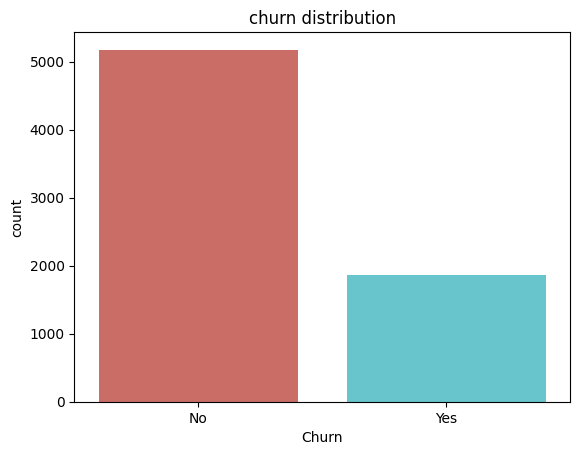

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
print(data['Churn'].value_counts())
sns.countplot(x='Churn',data=data,palette='hls')
plt.title('churn distribution')
plt.xlabel('Churn')
plt.ylabel('count')
plt.show()


data preprocessing handle missing value and incorrect value


pd.to_numeric convert the total charges column to numeric format
and
fillna replaces missing values with medain of the column to the maintain consistency in numerical values

In [ ]:
data['TotalCharges']=pd.to_numeric(data['TotalCharges'],errors='coerce')
data['TotalCharges'].fillna(data['TotalCharges'].median(),inplace=True)

/tmp/ipykernel_6966/4097101372.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(data['TotalCharges'].median(),inplace=True)


handling catagorial variables

some features like state international plan and voice mail plan are categorical and must be converted into numerical values
***lebelEncoder convert categorical values to numeric form
the loop iterates through each categorical column and applies fit_transform() to encode categorical variable into numbers

In [ ]:
from pandas.core.arrays import categorical
from sklearn.preprocessing import LabelEncoder
lebelencoder=LabelEncoder()
categorical_columns=['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','Churn']
for col in categorical_columns:
  data[col]=lebelencoder.fit_transform(data[col])

feature selection and splitting data

we want to seperate the feature(x) and taget(y) and split the data set into testing and training
x=data.drop(['customer_id','churn',axis=1]) removes the customerid (ireelevant for prediction) and churn column (target column) axix=0 menas row and axis=1 means column
y=data['churn'] defines y as the target_variables which want to predict
tarin_test_split splits data into 80% trainning and 20% testing for model evaluation
test size=0.2 means 80% train and 20% test and random_state=0 meaning same split evry run when run

In [ ]:
from sklearn.model_selection import train_test_split
x=data.drop(['customerID','Churn'],axis=1)
y=data['Churn']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

Feature scaling

*** standardscaler it's convert data into a balanced scale
*** fit_transform(x_train)=fits the scaler to the trainning data and transforms it
*** transform(x_test)=transforms the test data using the same scaling parameters

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

model training and prediction
** random fprest classifier helps to predicts catgories like yes or no pass or fail
1. create a random forest model
2. fit => train the  model and tech the mechine
3. now mechine is trainned

In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf=RandomForestClassifier()
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)

model evaluation

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print(f"model accuracy: {accuracy:.2f}")

model accuracy: 0.78


Cunfusion matrix and performance matrices

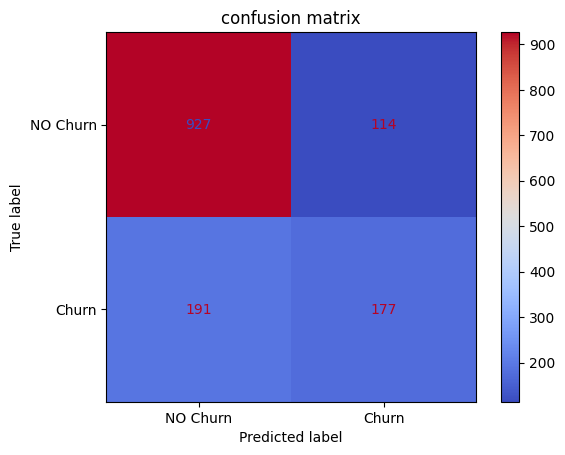

In [ ]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["NO Churn","Churn"])
disp.plot(cmap="coolwarm")
plt.title("confusion matrix")
plt.show()